# Learning-While-Doing: Optimizer Analysis

Compares **Random**, **IE** (max-std exploration), and **KG** (knowledge gradient) acquisition policies on the problem of finding the optimal cash buffer ratio C*.

Run the cells top-to-bottom. Each cell prints progress so you can see what's happening.

**Sections**
1. Setup
2. True cost curve (ground truth)
3. Single-seed session — posterior plots
4. Single-seed convergence
5. Multi-seed MAE comparison


## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt

from sim import SimConfig, simulate
from policy import (
    BeliefConfig, AcquisitionConfig, SessionConfig,
    RandomPolicy, IEPolicy, KGPolicy, Session,
)

# ── Shared config ────────────────────────────────────────────────────────────
SIM_CFG    = SimConfig(stationary=True, jump_rate_annual=12.0)
BELIEF_CFG = BeliefConfig(length_scale=0.04, signal_std=5_000.0, noise_std=3_000.0)
ACQ_CFG    = AcquisitionConfig(c_star_min=0.01, c_star_max=0.20,
                               grid_size=100, kg_n_mc=500)
SES_CFG    = SessionConfig(horizon_weeks=26, best_c_star_grid=200)

GRID    = np.linspace(ACQ_CFG.c_star_min, ACQ_CFG.c_star_max, 300)
N_STEPS = 20

COLORS = {"Random": "steelblue", "IE": "darkorange", "KG": "forestgreen"}

print("Setup complete.")

Setup complete.


## 2. True cost curve

Run the simulator at 40 C* values, averaged over 20 seeds each. This is the ground truth U-shape the optimizer is trying to learn.


Running 2000 simulations for true cost curve...
True C*  ≈ 0.0246
Min cost ≈ $485


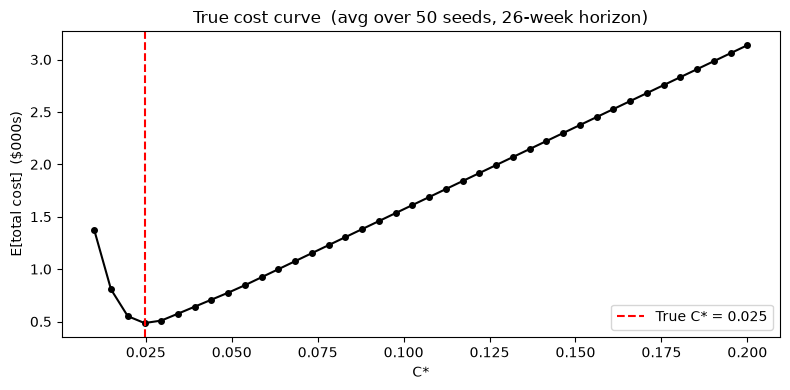

In [2]:
TRUE_GRID   = np.linspace(0.01, 0.20, 40)
N_SEEDS_TC  = 50

print(f"Running {len(TRUE_GRID) * N_SEEDS_TC} simulations for true cost curve...")

true_costs = np.array([
    np.mean([
        simulate(SIM_CFG, float(c), 26,
                 session_seed=999, experiment_index=i).total_cost
        for i in range(N_SEEDS_TC)
    ])
    for c in TRUE_GRID
])

TRUE_C_STAR = float(TRUE_GRID[np.argmin(true_costs)])
print(f"True C*  ≈ {TRUE_C_STAR:.4f}")
print(f"Min cost ≈ ${np.min(true_costs):,.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(TRUE_GRID, true_costs / 1_000, 'k-o', markersize=4)
ax.axvline(TRUE_C_STAR, color='r', linestyle='--', lw=1.5,
           label=f"True C* = {TRUE_C_STAR:.3f}")
ax.set_xlabel("C*")
ax.set_ylabel("E[total cost]  ($000s)")
ax.set_title(f"True cost curve  (avg over {N_SEEDS_TC} seeds, 26-week horizon)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Single-seed sessions — GP posterior vs true cost

Run each policy for `N_STEPS` steps from the same seed, then plot the posterior mean ± 1σ alongside the true cost curve.


In [3]:
def run_session(policy_cls, seed=0):
    policy = policy_cls(ACQ_CFG)
    s = Session(SIM_CFG, BELIEF_CFG, ACQ_CFG, SES_CFG, policy, session_seed=seed)
    for _ in range(N_STEPS):
        s.step()
    return s

print(f"Running {N_STEPS} steps × 3 policies (seed=0)...")
sessions = {
    "Random": run_session(RandomPolicy),
    "IE":     run_session(IEPolicy),
    "KG":     run_session(KGPolicy),
}

for name, s in sessions.items():
    err = abs(s.best_c_star() - TRUE_C_STAR)
    print(f"  {name:8s}  best_c*={s.best_c_star():.4f}  |error|={err:.4f}")

Running 20 steps × 3 policies (seed=0)...
  Random    best_c*=0.0272  |error|=0.0026
  IE        best_c*=0.0358  |error|=0.0112
  KG        best_c*=0.0272  |error|=0.0026


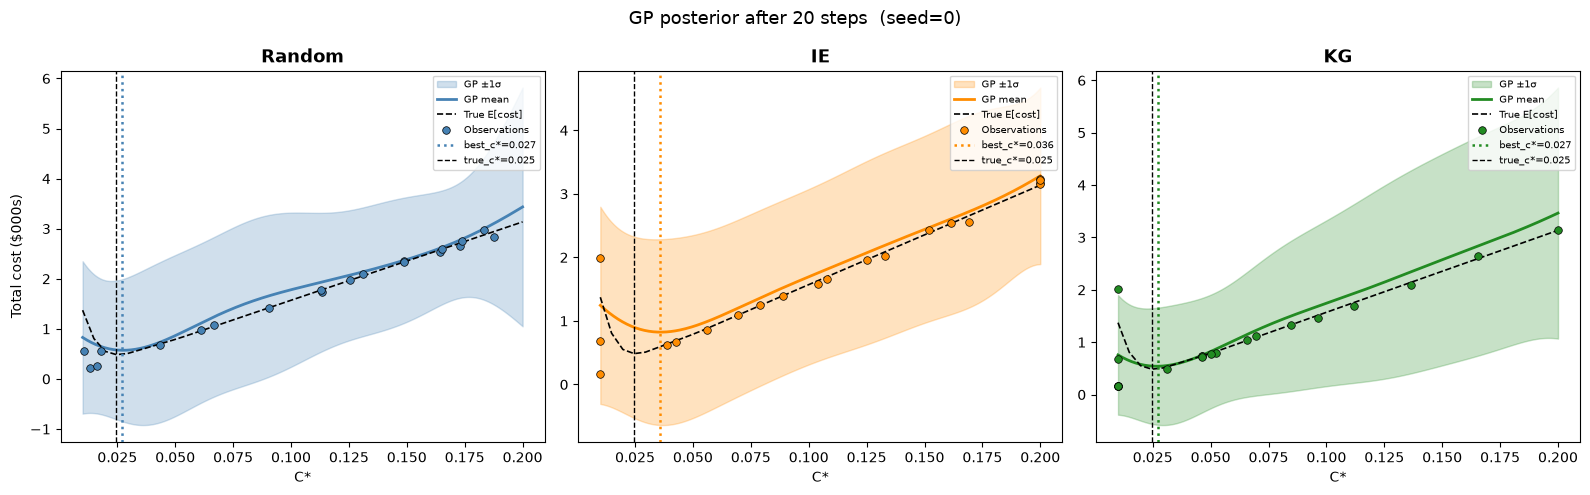

Saved → posterior_comparison.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, session) in zip(axes, sessions.items()):
    color = COLORS[name]
    mu, std = session.belief.posterior(GRID)

    ax.fill_between(GRID, (mu - std) / 1_000, (mu + std) / 1_000,
                    alpha=0.25, color=color, label="GP ±1σ")
    ax.plot(GRID, mu / 1_000, color=color, lw=2, label="GP mean")
    ax.plot(TRUE_GRID, true_costs / 1_000, 'k--', lw=1.2, label="True E[cost]")

    c_obs, cost_obs = zip(*session.history)
    ax.scatter(c_obs, [c / 1_000 for c in cost_obs],
               s=30, color=color, edgecolors='k', linewidths=0.5,
               zorder=5, label="Observations")

    best = session.best_c_star()
    ax.axvline(best, color=color, linestyle=':', lw=1.8,
               label=f"best_c*={best:.3f}")
    ax.axvline(TRUE_C_STAR, color='k', linestyle='--', lw=1,
               label=f"true_c*={TRUE_C_STAR:.3f}")

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel("C*")
    ax.legend(fontsize=7, loc='upper right')

axes[0].set_ylabel("Total cost ($000s)")
fig.suptitle(f"GP posterior after {N_STEPS} steps  (seed=0)", fontsize=13)
plt.tight_layout()
plt.savefig("posterior_comparison.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved → posterior_comparison.png")

## 4. Convergence of best_c_star over steps  (single seed)

How quickly does each policy's estimate of the optimal C* converge toward the true value?


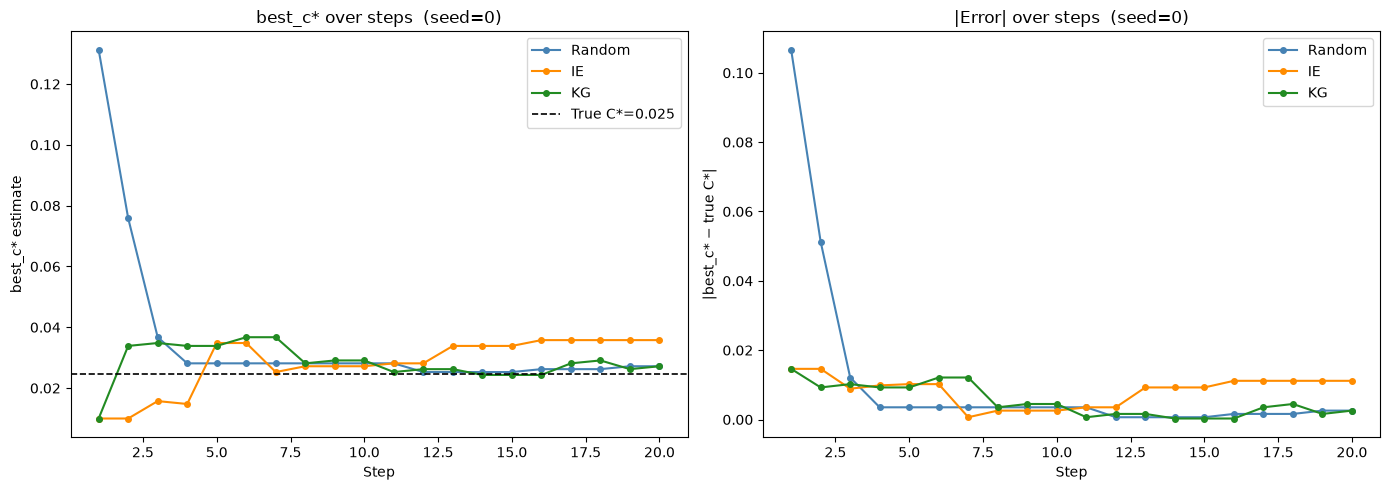

Saved → convergence_single_seed.png


In [5]:
def convergence_trace(policy_cls, seed=0):
    policy = policy_cls(ACQ_CFG)
    s = Session(SIM_CFG, BELIEF_CFG, ACQ_CFG, SES_CFG, policy, session_seed=seed)
    best_trace, err_trace = [], []
    for _ in range(N_STEPS):
        s.step()
        b = s.best_c_star()
        best_trace.append(b)
        err_trace.append(abs(b - TRUE_C_STAR))
    return best_trace, err_trace

traces = {}
for name, cls in [("Random", RandomPolicy), ("IE", IEPolicy), ("KG", KGPolicy)]:
    traces[name] = convergence_trace(cls, seed=0)

steps = range(1, N_STEPS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, (best_tr, _) in traces.items():
    ax.plot(steps, best_tr, marker='o', markersize=4, color=COLORS[name], label=name)
ax.axhline(TRUE_C_STAR, color='k', linestyle='--', lw=1.2,
           label=f"True C*={TRUE_C_STAR:.3f}")
ax.set_xlabel("Step")
ax.set_ylabel("best_c* estimate")
ax.set_title("best_c* over steps  (seed=0)")
ax.legend()

ax = axes[1]
for name, (_, err_tr) in traces.items():
    ax.plot(steps, err_tr, marker='o', markersize=4, color=COLORS[name], label=name)
ax.set_xlabel("Step")
ax.set_ylabel("|best_c* − true C*|")
ax.set_title("|Error| over steps  (seed=0)")
ax.legend()

plt.tight_layout()
plt.savefig("convergence_single_seed.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved → convergence_single_seed.png")

## 5. Multi-seed MAE comparison

Average absolute error in best_c_star over 15 independent seeds per policy. The shaded band is ± 1 std across seeds.

This removes the luck of a single seed and shows which policy is *systematically* better.


Running 15 seeds × 20 steps × 3 policies = 900 simulations...


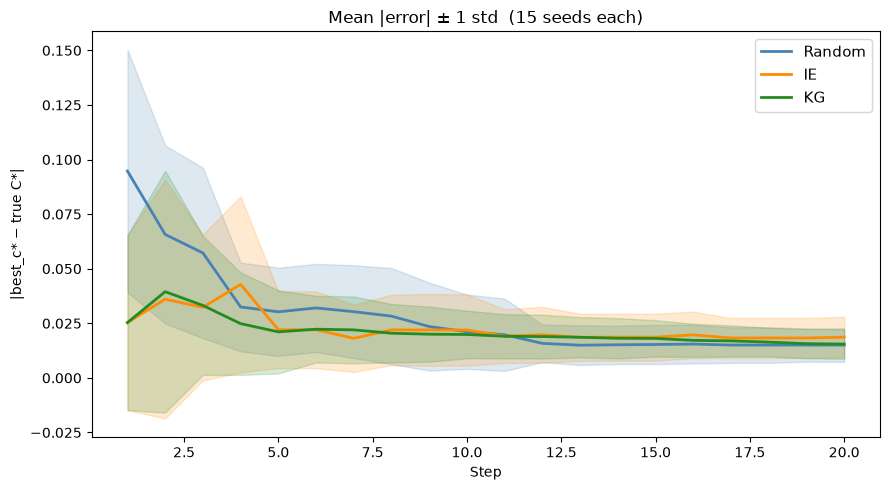

Saved → mae_comparison.png

Final |error| after 20 steps:
  Random    0.0150 ± 0.0077
  IE        0.0187 ± 0.0093
  KG        0.0155 ± 0.0068


In [6]:
K_SEEDS = 15
print(f"Running {K_SEEDS} seeds × {N_STEPS} steps × 3 policies "
      f"= {K_SEEDS * N_STEPS * 3} simulations...")

def multi_seed_mae(policy_cls, k=K_SEEDS, n=N_STEPS):
    all_err = []
    for seed in range(k):
        policy = policy_cls(ACQ_CFG)
        s = Session(SIM_CFG, BELIEF_CFG, ACQ_CFG, SES_CFG, policy, session_seed=seed)
        errs = []
        for _ in range(n):
            s.step()
            errs.append(abs(s.best_c_star() - TRUE_C_STAR))
        all_err.append(errs)
    arr = np.array(all_err)   # (k, n)
    return arr.mean(axis=0), arr.std(axis=0)

mae_results = {
    "Random": multi_seed_mae(RandomPolicy),
    "IE":     multi_seed_mae(IEPolicy),
    "KG":     multi_seed_mae(KGPolicy),
}

steps = range(1, N_STEPS + 1)
fig, ax = plt.subplots(figsize=(9, 5))
for name, (mean_err, std_err) in mae_results.items():
    color = COLORS[name]
    ax.plot(steps, mean_err, color=color, lw=2, label=name)
    ax.fill_between(steps,
                    mean_err - std_err,
                    mean_err + std_err,
                    alpha=0.18, color=color)

ax.set_xlabel("Step")
ax.set_ylabel("|best_c* − true C*|")
ax.set_title(f"Mean |error| ± 1 std  ({K_SEEDS} seeds each)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("mae_comparison.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved → mae_comparison.png")

print("\nFinal |error| after", N_STEPS, "steps:")
for name, (mean_err, std_err) in mae_results.items():
    print(f"  {name:8s}  {mean_err[-1]:.4f} ± {std_err[-1]:.4f}")